# Experimento 11 — Selección de features con chi² para reducir el sobreajuste

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento10.ipynb` (experimento 4 + stemming): La sección 1
repite de forma resumida la configuración común (misma semilla, mismo split y mismos folds). Los experimentos
anteriores **no se vuelven a ejecutar**: sus métricas se registran como valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 11 — Selección de features con chi²

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 2, "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
     "mejores_params": {"clf__C": 10}, "acc_train": 0.9999, "acc_cv": 0.8865, "std_cv": 0.0099, "f1_cv": 0.8908,
     "acc_test": 0.8992, "f1_test": 0.9031, "envio": "submission_02.csv", "kaggle_publico": 0.88},
    {"experimento": 4, "descripcion": "Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057,
     "f1_cv": 0.9055, "acc_test": 0.8975, "f1_test": 0.9021, "envio": "submission_04.csv", "kaggle_publico": None},
    {"experimento": 10, "descripcion": "Exp. 4 + stemming (Snowball) en los TF-IDF por partes, LinearSVC",
     "mejores_params": {"clf": "LinearSVC", "clf__C": 0.2}, "acc_train": 0.9776, "acc_cv": 0.9027,
     "std_cv": 0.0074, "f1_cv": 0.9071, "acc_test": 0.9, "f1_test": 0.9046,
     "envio": "submission_10.csv", "kaggle_publico": None},
]:
    resultados.append(fila)

# Experimento 10 (experimento10.ipynb, sección 2.4): accuracy por fold con los mismos folds, y de entrenamiento
ACC_FOLDS_E10 = np.array([0.9094, 0.9, 0.9021, 0.9115, 0.8906])
ACC_TRAIN_E10 = 0.9776

# Prueba de robustez en test de los experimentos 4 y 10 (sus notebooks)
ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 4", "escenario": "Original", "accuracy": 0.8975},
    {"modelo": "Exp. 4", "escenario": "Oraciones desordenadas", "accuracy": 0.7358},
    {"modelo": "Exp. 4", "escenario": "Última oración al inicio", "accuracy": 0.5946},
    {"modelo": "Exp. 10", "escenario": "Original", "accuracy": 0.9},
    {"modelo": "Exp. 10", "escenario": "Oraciones desordenadas", "accuracy": 0.7358},
    {"modelo": "Exp. 10", "escenario": "Última oración al inicio", "accuracy": 0.5908},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
3,10,"Exp. 4 + stemming (Snowball) en los TF-IDF por partes, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9776,0.9027,0.0074,0.9071,0.9000,0.9046,submission_10.csv,NaN


## 2. Experimento 11 — Selección de features con chi²

**Motivación:** En el experimento 10 la accuracy de entrenamiento es
0.978 y la de validación 0.903: una brecha de ≈ 7.5 puntos, lo que indica sobreajuste. La causa es la
dimensión: el modelo tiene decenas de miles de n-gramas para 9.600 reseñas, y con tantas features un clasificador
lineal siempre encuentra combinaciones que separan el entrenamiento aunque no signifiquen nada (nombres de producto,
detalles del envío, palabras que aparecen en dos o tres reseñas).

**Idea:** quedarse solo con los **`k` n-gramas más asociados con la etiqueta** según la prueba **chi²**
(`SelectKBest(chi2, k)`), entre el TF-IDF y el clasificador. Menos features significa una menor capacidad de memorización del modelo. 

**Hipótesis:** hay un `k` mucho menor que el total con el que la accuracy de validación se mantiene y la brecha con
el entrenamiento se reduce de forma clara.

**Proceso:**
1. Diagnóstico: cuántas features tiene el modelo y qué tan raras son.
2. Curva de accuracy de entrenamiento y validación según `k`.
3. Comparación con las otras dos formas de quitar capacidad al mismo modelo: más regularización (`C` menor) y
   vocabulario más estricto (`min_df` mayor).
4. Elección de `k`: el **más pequeño** cuya accuracy de CV queda dentro de una desviación estándar de la mejor.
5. Modelo final (ajustando `C` de nuevo), test, features seleccionadas, robustez y envío.

### 2.1 Definiciones

Las mismas funciones y el transformador `PartesE5` de los experimentos 4 y 5, y el stemming del experimento 10
(`experimento10.ipynb`, sección 2.2). Lo único nuevo es el paso `sel` del pipeline.

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

In [7]:
from nltk.stem import SnowballStemmer
from sklearn.feature_selection import SelectKBest, chi2

STEMMER = SnowballStemmer("spanish")
PATRON_TOKEN = re.compile(r"(?u)\b\w\w+\b")
_RAICES = {}


def raiz(palabra):
    if palabra not in _RAICES:
        _RAICES[palabra] = STEMMER.stem(palabra)
    return _RAICES[palabra]


def tokenizar_con_stemming(texto):
    return [raiz(p) for p in PATRON_TOKEN.findall(texto)]


def tfidf_partes(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True,
                           tokenizer=tokenizar_con_stemming, token_pattern=None)


COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def pipeline_e11(k="all", min_df=2, C=0.2):
    """Modelo del experimento 10 con selección de las k mejores features según chi² (k="all": sin selección)."""
    return Pipeline([
        ("partes", PartesE5()),
        ("tfidf", ColumnTransformer([(c, tfidf_partes(min_df), c) for c in COLUMNAS_PARTES])),
        ("sel", SelectKBest(chi2, k=k)),
        ("clf", LinearSVC(C=C, max_iter=5000, random_state=SEED)),
    ])

### 2.2 Diagnóstico: cuántas features hay y qué tan raras son

In [8]:
modelo_e10 = pipeline_e11().fit(X_train, y_train)            # k="all": es el modelo del experimento 10
M_train = modelo_e10[:2].transform(X_train)                  # matriz TF-IDF (reseñas x features)
nombres = modelo_e10.named_steps["tfidf"].get_feature_names_out()
parte = np.array([n.split("__")[0] for n in nombres])
n_resenas = np.asarray((M_train > 0).sum(axis=0)).ravel()   # en cuántas reseñas aparece cada feature
N_FEATURES = len(nombres)

diagnostico = pd.DataFrame([
    {"parte": p, "features": int((parte == p).sum()),
     "% en 2 a 3 reseñas": 100 * (n_resenas[parte == p] <= 3).mean(),
     "% en 10 reseñas o menos": 100 * (n_resenas[parte == p] <= 10).mean()}
    for p in COLUMNAS_PARTES
] + [{"parte": "TOTAL", "features": N_FEATURES, "% en 2 a 3 reseñas": 100 * (n_resenas <= 3).mean(),
      "% en 10 reseñas o menos": 100 * (n_resenas <= 10).mean()}]).round(1)
print(f"Reseñas de entrenamiento: {M_train.shape[0]:,} | features: {N_FEATURES:,} "
      f"({N_FEATURES / M_train.shape[0]:.1f} features por reseña)")
diagnostico

Reseñas de entrenamiento: 9,600 | features: 37,360 (3.9 features por reseña)


,parte,features,% en 2 a 3 reseñas,% en 10 reseñas o menos
0,texto,20234,39.0,70.9
1,ultima_op,8301,40.9,75.1
2,tras_sin_ev,8825,41.7,75.4
3,TOTAL,37360,40.1,72.9


**Lectura**

- El modelo del experimento 10 tiene **37.360 features para 9.600 reseñas**: casi 4 features por cada ejemplo de
  entrenamiento. Con más parámetros que datos, un clasificador lineal puede separar el entrenamiento casi a la
  perfección (0,978) sin que eso diga nada sobre reseñas nuevas.
- **El 40 % de las features aparece en solo 2 o 3 reseñas** y el 73 % en 10 o menos. Su peso se estima con
  muy pocos ejemplos: es donde el modelo memoriza.
- Más de la mitad de las features (20.234) viene del **texto completo**, la parte que menos información tiene sobre
  el veredicto (experimento 2: el texto completo solo da 0,74; la última oración, 0,85).

### 2.3 Curva de accuracy según `k`

**Cómo funciona chi²:** para cada feature se mide si su presencia depende de la clase, comparando cuánto TF-IDF
acumula en cada clase con lo que acumularía si fuera independiente de la etiqueta. Una palabra repartida por igual
entre `negativo`, `neutral` y `positivo` tiene chi² ≈ 0; una concentrada en una clase tiene chi² alto.
`SelectKBest` conserva las `k` de mayor puntaje.

**¿Es leakage?** chi² **usa las etiquetas**, así que debe ir **dentro del `Pipeline`**: en cada fold se calcula solo
con las reseñas de entrenamiento de ese fold. Si se seleccionaran las features una vez con todo `X_train` y después
se hiciera la CV, las reseñas de validación habrían ayudado a elegirlas y la accuracy saldría inflada.

`GridSearchCV` recorre `k` con los mismos 5 folds (`k = "all"` es el experimento 10).

In [9]:
VALORES_K = [1000, 2000, 3000, 5000, 8000, 12000, 20000, "all"]
busqueda_k = GridSearchCV(pipeline_e11(), {"sel__k": VALORES_K}, cv=skf, scoring=SCORING, refit=False,
                          return_train_score=True, n_jobs=-1)
busqueda_k.fit(X_train, y_train)

cv_k = busqueda_k.cv_results_
curva = pd.DataFrame({
    "k": [N_FEATURES if k == "all" else k for k in VALORES_K],
    "acc_train": cv_k["mean_train_accuracy"],
    "acc_cv": cv_k["mean_test_accuracy"],
    "std_cv": cv_k["std_test_accuracy"],
    "f1_cv": cv_k["mean_test_f1_macro"],
})
curva["brecha"] = curva["acc_train"] - curva["acc_cv"]
curva["folds que gana al exp. 10"] = [
    int((np.round([cv_k[f"split{j}_test_accuracy"][i] for j in range(5)], 4) > ACC_FOLDS_E10).sum())
    for i in range(len(VALORES_K))]
curva.round(4)

,k,acc_train,acc_cv,std_cv,f1_cv,brecha,folds que gana al exp. 10
0,1000,0.8857,0.8670,0.0101,0.8713,0.0187,0
1,2000,0.9124,0.8918,0.0113,0.8961,0.0207,1
2,3000,0.9236,0.8995,0.0073,0.9039,0.0242,1
3,5000,0.9317,0.9011,0.0087,0.9056,0.0305,1
4,8000,0.9408,0.9009,0.0062,0.9054,0.0398,2
5,12000,0.9508,0.9028,0.0054,0.9072,0.0480,3
6,20000,0.9653,0.9016,0.0053,0.9060,0.0637,3
7,37360,0.9776,0.9027,0.0074,0.9071,0.0749,0


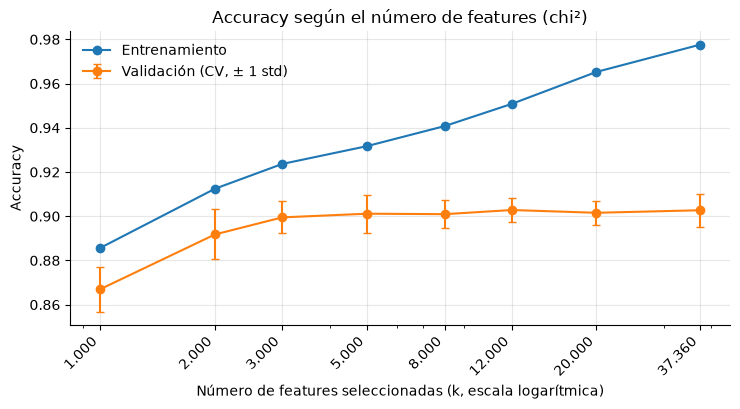

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(curva["k"], curva["acc_train"], marker="o", label="Entrenamiento")
ax.errorbar(curva["k"], curva["acc_cv"], yerr=curva["std_cv"], marker="o", capsize=3, label="Validación (CV, ± 1 std)")
ax.set_xscale("log")
ax.set_xticks(curva["k"])
ax.set_xticklabels([f"{k:,}".replace(",", ".") for k in curva["k"]], rotation=45, ha="right")
ax.set_xlabel("Número de features seleccionadas (k, escala logarítmica)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy según el número de features (chi²)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Lectura**

- **La accuracy de validación es plana entre 3.000 y 37.360 features** (0,8995 a 0,9028): todas las diferencias son
  menores que la desviación entre folds (0,005–0,009). Las ≈ 34.000 features de menor chi² no aportan nada medible.
- **La accuracy de entrenamiento sí baja** de forma continua, de 0,978 a 0,924: lo que se elimina es lo que el modelo
  usaba para memorizar. La brecha pasa de 7,5 puntos (todas las features) a 2,4 (3.000).
- **Por debajo de 3.000 el modelo empieza a perder información útil:** con 2.000 features la CV cae a 0,892 y con
  1.000 a 0,867. Ahí ya se están descartando palabras de opinión.
- Ningún `k` **mejora** al experimento 10 de forma consistente (el mejor, 12.000, gana 3 de 5 folds con +0,01
  puntos). La selección de features no sube la accuracy: la mantiene con un modelo mucho más pequeño.

### 2.4 Comparación con otras formas de quitar capacidad

Hay otras dos maneras clásicas de reducir el sobreajuste de este mismo modelo sin seleccionar features con la
etiqueta:

- **Más regularización:** bajar `C` en el LinearSVC (pesos más pequeños).
- **Vocabulario más estricto:** subir `min_df` en el TF-IDF (descartar n-gramas que aparecen en pocas reseñas, sin
  mirar la etiqueta).

Se evalúan con los mismos folds y se comparan en un mismo plano: brecha entrenamiento–validación (sobreajuste) frente
a accuracy de validación. Lo deseable es estar **arriba y a la izquierda**.

In [11]:
from sklearn.model_selection import cross_validate

otras = {
    f"C = {C}".replace(".", ","): {"C": C} for C in [0.02, 0.05, 0.1]
} | {f"min_df = {m}": {"min_df": m} for m in [5, 10, 20]}

filas = [{"método": "chi²", "configuración": f"k = {int(k):,}".replace(",", "."), "features": int(k),
          "acc_train": a, "acc_cv": c, "std_cv": s}
         for k, a, c, s in zip(curva["k"], curva["acc_train"], curva["acc_cv"], curva["std_cv"])]
filas[-1].update(método="exp. 10", configuración="sin reducción")
for nombre, params in otras.items():
    cv = cross_validate(pipeline_e11(**params), X_train, y_train, cv=skf, return_train_score=True, n_jobs=-1)
    n = pipeline_e11(**params).fit(X_train, y_train)[:2].transform(X_train.iloc[:5]).shape[1]
    filas.append({"método": "C menor" if "C" in params else "min_df mayor", "configuración": nombre, "features": n,
                  "acc_train": cv["train_score"].mean(), "acc_cv": cv["test_score"].mean(),
                  "std_cv": cv["test_score"].std()})

capacidad = pd.DataFrame(filas)
capacidad["brecha"] = capacidad["acc_train"] - capacidad["acc_cv"]
capacidad.round(4)

,método,configuración,features,acc_train,acc_cv,std_cv,brecha
0,chi²,k = 1.000,1000,0.8857,0.8670,0.0101,0.0187
1,chi²,k = 2.000,2000,0.9124,0.8918,0.0113,0.0207
2,chi²,k = 3.000,3000,0.9236,0.8995,0.0073,0.0242
3,chi²,k = 5.000,5000,0.9317,0.9011,0.0087,0.0305
4,chi²,k = 8.000,8000,0.9408,0.9009,0.0062,0.0398
5,chi²,k = 12.000,12000,0.9508,0.9028,0.0054,0.0480
6,chi²,k = 20.000,20000,0.9653,0.9016,0.0053,0.0637
7,exp. 10,sin reducción,37360,0.9776,0.9027,0.0074,0.0749
8,C menor,"C = 0,02",37360,0.9211,0.8863,0.0093,0.0348
9,C menor,"C = 0,05",37360,0.9403,0.8965,0.0071,0.0439


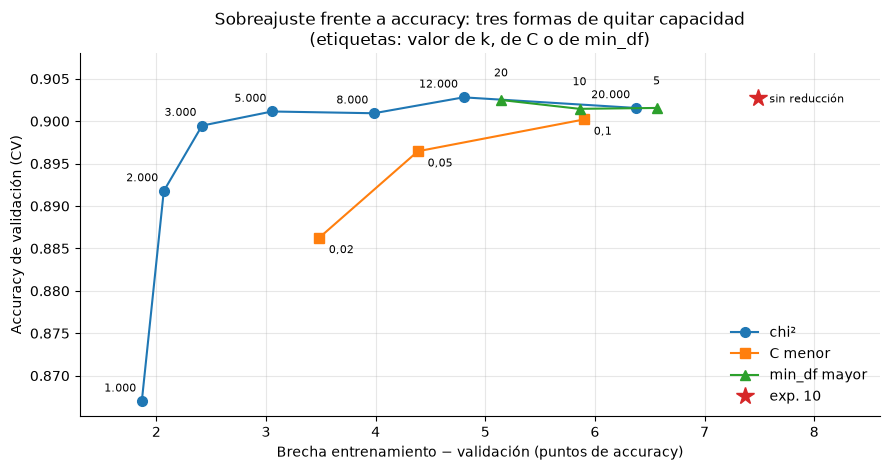

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ESTILO = {   # método: (marcador, desplazamiento de la etiqueta, alineación)
    "chi²": ("o", (-4, 7), "right"),
    "C menor": ("s", (7, -11), "left"),
    "min_df mayor": ("^", (0, 17), "center"),
    "exp. 10": ("*", (8, -3), "left"),
}
for metodo, (marcador, desplazamiento, alineacion) in ESTILO.items():
    d = capacidad[capacidad["método"] == metodo]
    ax.plot(100 * d["brecha"], d["acc_cv"], marker=marcador, linestyle="-" if len(d) > 1 else "",
            markersize=13 if metodo == "exp. 10" else 7, label=metodo)
    for _, f in d.iterrows():
        etiqueta = f["configuración"].split("= ")[-1]          # solo el valor: "3.000", "0,05", "10"
        ax.annotate(etiqueta, (100 * f["brecha"], f["acc_cv"]), textcoords="offset points",
                    xytext=desplazamiento, ha=alineacion, fontsize=8)
ax.set_xlim(1.3, 8.6)
ax.set_ylim(top=0.908)
ax.set_xlabel("Brecha entrenamiento − validación (puntos de accuracy)")
ax.set_ylabel("Accuracy de validación (CV)")
ax.set_title("Sobreajuste frente a accuracy: tres formas de quitar capacidad\n"
             "(etiquetas: valor de k, de C o de min_df)")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

**Lectura**

- **chi² es la mejor de las tres formas de quitar capacidad.** A igual brecha, conserva más accuracy:

  | Brecha ≈ | chi² | `C` menor | `min_df` mayor |
  |---|---|---|---|
  | 3,0–3,5 puntos | 0,9011 (`k = 5.000`) | 0,8863 (`C = 0,02`) | no llega |
  | 4,0–4,4 puntos | 0,9009 (`k = 8.000`) | 0,8965 (`C = 0,05`) | no llega |
  | 5,1–5,9 puntos | 0,9028 (`k = 12.000`, brecha 4,8) | 0,9002 (`C = 0,1`) | 0,9025 (`min_df = 20`) |

- **Bajar `C`** encoge todos los pesos por igual, los de las palabras de opinión y los del ruido: reduce la brecha,
  pero pierde accuracy desde el primer paso (−0,25 puntos con `C = 0,1`, −1,6 con `C = 0,02`).
- **Subir `min_df`** no pierde accuracy (0,9015–0,9025), pero se estanca: aun con `min_df = 20` (6.554 features) la
  brecha sigue en 5,1 puntos. Descarta por frecuencia sin mirar la etiqueta, así que conserva n-gramas frecuentes que
  no distinguen clases (`lo compre`, `en la`, `a mi casa`).
- **chi²** elige justamente por relación con la etiqueta, y por eso llega a brechas de 2–3 puntos con la accuracy
  intacta.

### 2.5 Elección de `k`

**Regla (fijada antes de mirar el test):** de todos los `k` cuya accuracy de CV está **dentro de una desviación
estándar entre folds** de la mejor, se elige el **más pequeño**. Es la regla del proyecto "ante un empate, lo más
simple", aplicada al número de features: si dos modelos no se distinguen en validación, se prefiere el que tiene
menos capacidad para sobreajustar.

In [13]:
i_mejor = curva["acc_cv"].idxmax()
umbral = curva.loc[i_mejor, "acc_cv"] - curva.loc[i_mejor, "std_cv"]
candidatos = curva[curva["acc_cv"] >= umbral]
K_ELEGIDO = int(candidatos["k"].min())
i_k = curva.index[curva["k"] == K_ELEGIDO][0]

print(f"Mejor accuracy de CV: {curva.loc[i_mejor, 'acc_cv']:.4f} ± {curva.loc[i_mejor, 'std_cv']:.4f} "
      f"(k = {int(curva.loc[i_mejor, 'k']):,})".replace(",", "."))
print(f"Umbral (mejor − 1 std): {umbral:.4f}")
print(f"k dentro del umbral: {[int(k) for k in candidatos['k']]}")
print(f"k elegido: {K_ELEGIDO}  ({K_ELEGIDO / N_FEATURES:.1%} de las features)")

acc_folds_k = np.array([cv_k[f"split{j}_test_accuracy"][i_k] for j in range(5)])
comparacion = pd.DataFrame({"[ref. exp. 10]": ACC_FOLDS_E10, f"chi² k = {K_ELEGIDO}": acc_folds_k},
                           index=[f"fold {k}" for k in range(1, 6)]).T
comparacion["media"] = comparacion.mean(axis=1)
comparacion.round(4)

Mejor accuracy de CV: 0.9028 ± 0.0054 (k = 12.000)
Umbral (mejor − 1 std): 0.8974
k dentro del umbral: [3000, 5000, 8000, 12000, 20000, 37360]
k elegido: 3000  (8.0% de las features)


,fold 1,fold 2,fold 3,fold 4,fold 5,media
[ref. exp. 10],0.9094,0.9,0.9021,0.9115,0.8906,0.9027
chi² k = 3000,0.9005,0.9,0.9073,0.9036,0.8859,0.8995


**Lectura**

- La mejor accuracy de CV es 0,9028 ± 0,0054 (`k = 12.000`), así que el umbral es 0,8974. Todos los `k` desde 3.000
  quedan dentro: en validación no se distinguen.
- Por la regla, se elige el más pequeño: **`k = 3.000`**, el 8 % de las features.
- Fold por fold frente al experimento 10 (con el mismo `C = 0,2`) el resultado es mixto: gana en el fold 3, empata en
  el 2 y pierde en los otros tres; en media queda 0,3 puntos por debajo. Es un empate dentro del ruido, no una
  mejora. La sección siguiente ajusta `C` para este número de features.

### 2.6 Modelo del experimento 11

Con `k` fijo, se ajusta de nuevo `C`: con muchas menos features el óptimo puede cambiar (cada experimento ajusta su
propio `C`). Se usa LinearSVC, el clasificador elegido en los experimentos 4 y 10.

In [14]:
busqueda_e11 = GridSearchCV(pipeline_e11(k=K_ELEGIDO), {"clf__C": [0.1, 0.2, 0.5, 1]}, cv=skf, scoring=SCORING,
                            refit="accuracy", return_train_score=True, n_jobs=-1)
busqueda_e11.fit(X_train, y_train)

print(f"Mejor C: {busqueda_e11.best_params_['clf__C']} | Accuracy CV: {busqueda_e11.best_score_:.4f}")
tabla_e11 = tabla_cv(busqueda_e11)
tabla_e11.insert(0, "C", tabla_e11.pop("params").map(lambda p: p["clf__C"]))
tabla_e11["brecha"] = (tabla_e11["acc_train"] - tabla_e11["acc_cv"]).round(4)
tabla_e11

Mejor C: 0.5 | Accuracy CV: 0.9015


,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste,brecha
2,0.5,0.9337,0.9015,0.0048,0.9060,13.9875,0.0322
3,1.0,0.9428,0.9005,0.0054,0.9051,14.0096,0.0423
1,0.2,0.9236,0.8995,0.0073,0.9039,13.9835,0.0241
0,0.1,0.9170,0.8979,0.0085,0.9022,13.6858,0.0191


In [15]:
i = busqueda_e11.best_index_
ACC_FOLDS_E11 = np.array([busqueda_e11.cv_results_[f"split{k}_test_accuracy"][i] for k in range(5)])
print("Folds en que el exp. 11 gana al exp. 10:", int((np.round(ACC_FOLDS_E11, 4) > ACC_FOLDS_E10).sum()), "de 5")
pd.DataFrame({
    "features": [N_FEATURES, K_ELEGIDO],
    "acc_train": [ACC_TRAIN_E10, busqueda_e11.cv_results_["mean_train_accuracy"][i]],
    "acc_cv": [ACC_FOLDS_E10.mean(), ACC_FOLDS_E11.mean()],
    "std_cv": [ACC_FOLDS_E10.std(), ACC_FOLDS_E11.std()],
}, index=["Exp. 10", "Exp. 11"]).assign(brecha=lambda d: d["acc_train"] - d["acc_cv"]).round(4)

Folds en que el exp. 11 gana al exp. 10: 3 de 5


,features,acc_train,acc_cv,std_cv,brecha
Exp. 10,37360,0.9776,0.9027,0.0074,0.0749
Exp. 11,3000,0.9337,0.9015,0.0048,0.0323


**Lectura**

- Con solo 3.000 features el `C` óptimo **sube de 0,2 a 0,5**: al haber quitado el ruido con la selección, el
  clasificador necesita menos regularización. Es la razón por la que cada experimento ajusta su propio `C`.
- **Accuracy de CV = 0,9015 ± 0,0048**, frente a 0,9027 ± 0,0074 del experimento 10: −0,12 puntos, un empate (gana 3
  de 5 folds), y con la **menor desviación entre folds** de los modelos de un nivel.
- **La brecha baja de 7,5 a 3,2 puntos** (entrenamiento 0,934 frente a 0,978), con **12 veces menos features**.
- Con `C = 0,2` la brecha sería aún menor (2,4) con 0,2 puntos menos de CV. Se mantiene el criterio del proyecto: se
  elige por accuracy de CV.

### 2.7 Evaluación en test

Test -> accuracy: 0.8967 | F1 macro: 0.9014

              precision    recall  f1-score   support

    negativo      0.852     0.860     0.856       843
     neutral      0.989     0.999     0.994       715
    positivo      0.862     0.847     0.854       842

    accuracy                          0.897      2400
   macro avg      0.901     0.902     0.901      2400
weighted avg      0.896     0.897     0.896      2400



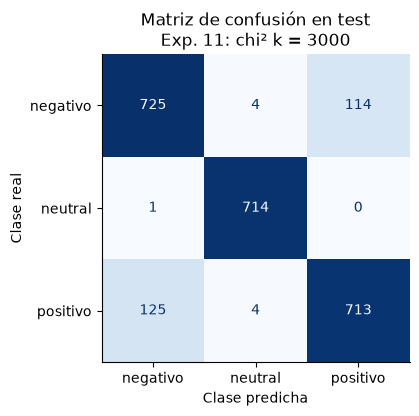

Negativo vs positivo en test: 0.853


In [16]:
metricas_e11 = evaluar_en_test(busqueda_e11.best_estimator_, f"Exp. 11: chi² k = {K_ELEGIDO}")
np_test = (y_test != "neutral").to_numpy()
print(f"Negativo vs positivo en test: {(metricas_e11['pred'][np_test] == y_test.to_numpy()[np_test]).mean():.3f}")

### 2.8 Qué features quedan

In [17]:
final = busqueda_e11.best_estimator_
sel = final.named_steps["sel"]
nombres_f = final.named_steps["tfidf"].get_feature_names_out()
parte_f = np.array([n.split("__")[0] for n in nombres_f])
queda = sel.get_support()

resumen = pd.DataFrame([{"parte": p, "features antes": int((parte_f == p).sum()),
                         "features seleccionadas": int((queda & (parte_f == p)).sum()),
                         "% que se conserva": 100 * (queda & (parte_f == p)).sum() / (parte_f == p).sum()}
                        for p in COLUMNAS_PARTES]).round(1)
print(f"Features: {len(nombres_f):,} -> {int(queda.sum()):,}".replace(",", "."))
resumen

Features: 37.360 -> 3.000


,parte,features antes,features seleccionadas,% que se conserva
0,texto,20234,846,4.2
1,ultima_op,8301,1111,13.4
2,tras_sin_ev,8825,1043,11.8


In [18]:
# Las 25 features con mayor chi² (las primeras que se conservan) y una muestra de las descartadas
orden = np.argsort(sel.scores_)[::-1]
descartadas = np.random.default_rng(SEED).choice(np.where(~queda)[0], 25, replace=False)
pd.DataFrame({
    "mayor chi² (se conservan)": [f"{nombres_f[j]} ({sel.scores_[j]:.0f})" for j in orden[:25]],
    "descartadas (muestra al azar)": [f"{nombres_f[j]} ({sel.scores_[j]:.2f})" for j in descartadas],
})

,mayor chi² (se conservan),descartadas (muestra al azar)
0,ultima_op__nad mas (138),ultima_op__par configur (0.05)
1,ultima_op__por ahor (132),texto__paquet al (5.25)
2,tras_sin_ev__por ahor (118),texto__estand aqui (0.87)
3,ultima_op__mas que (117),tras_sin_ev__alcanz ver (1.96)
4,ultima_op__guard (117),texto__envi escrib (0.16)
5,tras_sin_ev__nad mas (112),tras_sin_ev__asi qued (0.30)
6,ultima_op__nad (107),ultima_op__instal de (1.39)
7,ultima_op__caj (104),tras_sin_ev__floj en (2.37)
8,ultima_op__guard en (102),ultima_op__usad todavi (4.05)
9,tras_sin_ev__mas que (101),texto__deficient desd (0.61)


In [19]:
# Raíces y bigramas con mayor peso por clase en el clasificador final
nombres_sel = nombres_f[queda]
clf = final.named_steps["clf"]
pd.DataFrame({clase: [f"{nombres_sel[j]} ({clf.coef_[c][j]:.2f})" for j in clf.coef_[c].argsort()[::-1][:12]]
              for c, clase in enumerate(clf.classes_)})[CLASES]

,negativo,neutral,positivo
0,ultima_op__poc fiabl (2.59),texto__kil (0.91),texto__es just (2.30)
1,ultima_op__inconsistent (2.41),texto__pedi por (0.77),ultima_op__confiabl (2.08)
2,tras_sin_ev__poc fiabl (2.39),texto__usb (0.76),tras_sin_ev__resistent (2.08)
3,ultima_op__fragil (2.27),texto__vien (0.72),tras_sin_ev__comodisim (2.07)
4,ultima_op__incumplidor (2.24),texto__tra (0.72),ultima_op__liger (2.06)
5,ultima_op__chapucer (2.19),ultima_op__todavi (0.72),ultima_op__decent (2.05)
6,ultima_op__delic (2.14),ultima_op__guard (0.72),ultima_op__buenisim (2.02)
7,ultima_op__aparat (2.13),ultima_op__ver (0.71),ultima_op__rapidisim (2.01)
8,tras_sin_ev__pobr (2.09),texto__paquet (0.70),tras_sin_ev__formid (1.98)
9,tras_sin_ev__malisim (2.08),texto__unidad (0.70),tras_sin_ev__buenisim (1.97)


**Lectura**

- **La selección confirma dónde está la información.** Se conserva el 13,4 % de las features de la última oración con
  opinión y el 11,8 % de las del texto tras el último conector, pero solo el **4,2 % de las del texto completo**. chi²
  llega por su cuenta a la misma conclusión del experimento 2: el veredicto está al final.
- **Las features con mayor chi² son las de `neutral`** (`nad mas`, `por ahor`, `guard`, `caj`, `todavi no`), no las
  palabras de opinión. chi² mide la relación con las tres clases a la vez, y `neutral` es la clase más fácil de
  separar: cuando la última oración es descriptiva, la reseña casi siempre es neutral. Las palabras de polaridad
  entran después, y por eso el modelo se degrada al bajar de 3.000.
- **Las descartadas** son, como se esperaba, combinaciones circunstanciales (`paquet al`, `televisor por`,
  `reinici un`, `configur esa`). También caen algunas con sentido pero muy poco frecuentes (`qued estupend`,
  `deficient desd`): el costo de la selección.
- En el clasificador final los pesos mayores siguen siendo palabras de opinión claras (`poc fiabl`, `fragil`,
  `chapucer`, `malisim` / `confiabl`, `resistent`, `comodisim`, `buenisim`), ahora con pesos más altos porque hay
  menos features entre las que repartir y menos regularización.

### 2.9 Prueba de robustez en test

In [20]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 11", "escenario": e, "accuracy": accuracy_score(y_test, busqueda_e11.best_estimator_.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 10,Exp. 11,Exp. 4
escenario,,,
Original,0.9000,0.8967,0.8975
Oraciones desordenadas,0.7358,0.7238,0.7358
Última oración al inicio,0.5908,0.5721,0.5946


### 2.10 Registro y envío

In [21]:
registrar_resultado(
    experimento=11,
    descripcion=f"Exp. 10 + selección de features chi² (k = {K_ELEGIDO}), LinearSVC",
    busqueda=busqueda_e11,
    metricas_test=metricas_e11,
    envio="submission_11.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,0.88
2,4,"Texto completo + última oración con opinión (detector) + tras conector sin evasivas, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9770,0.9009,0.0057,0.9055,0.8975,0.9021,submission_04.csv,NaN
3,10,"Exp. 4 + stemming (Snowball) en los TF-IDF por partes, LinearSVC","{'clf': 'LinearSVC', 'clf__C': 0.2}",0.9776,0.9027,0.0074,0.9071,0.9000,0.9046,submission_10.csv,NaN
4,11,"Exp. 10 + selección de features chi² (k = 3000), LinearSVC",{'clf__C': 0.5},0.9337,0.9015,0.0048,0.9060,0.8967,0.9014,submission_11.csv,NaN


In [22]:
envio_e11 = generar_envio(busqueda_e11, numero=11)

Envío guardado en envios/submission_11.csv y modelo en modelos/modelo_11.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.3
neutral     27.8
positivo    36.9


### 2.11 Análisis del experimento 11

**Resultados:** accuracy de CV = **0,9015 ± 0,0048** (LinearSVC, `C = 0,5`, 3.000 features) y accuracy en test =
**0,8967**.

| | Exp. 4 | Exp. 10 | Exp. 11 |
|---|---|---|---|
| Cambio | — | Stemming | Stemming + chi² (`k = 3.000`) |
| Features | 42.177 | 37.360 | **3.000** |
| Accuracy de entrenamiento | 0,9770 | 0,9776 | 0,9337 |
| Accuracy CV | 0,9009 ± 0,006 | **0,9027** ± 0,007 | 0,9015 ± **0,005** |
| Brecha entrenamiento − CV | 7,6 puntos | 7,5 puntos | **3,2 puntos** |
| Accuracy test | 0,8975 | **0,9000** | 0,8967 |
| Test, oraciones desordenadas | 0,736 | 0,736 | 0,724 |
| Test, última oración al inicio | 0,595 | 0,591 | 0,572 |

1. **La hipótesis se confirma.** Con el 8 % de las features la accuracy de validación se mantiene (0,9015 frente a
   0,9027, empate) y la brecha entre entrenamiento y validación baja a **menos de la mitad** (de 7,5 a 3,2 puntos).
2. **No mejora la accuracy, y no era el objetivo.** En CV queda 0,12 puntos por debajo del experimento 10 y en test
   0,33 (8 reseñas de 2.400); las dos diferencias están dentro del ruido (desviación entre folds ≈ 0,005–0,007, error
   estándar del test ≈ 0,006). Lo que cambia es la **calidad del modelo**: es 12 veces más pequeño, su accuracy de
   entrenamiento se parece más a la real y varía menos entre folds.
3. **chi² es mejor que regularizar más o que subir `min_df`** para este fin: es la única de las tres que lleva la
   brecha a ≈ 3 puntos sin perder accuracy (sección 2.4).
4. **Queda sobreajuste:** 3,2 puntos de brecha no es cero. Parte es estructural: el detector de opinión y el TF-IDF
   se ajustan con las mismas reseñas de entrenamiento, y ≈ 16 % de las reseñas negativo/positivo tiene una etiqueta
   prácticamente aleatoria (experimento 4), que el modelo solo puede "acertar" en entrenamiento memorizándola.
5. **Límites:**
   - La **robustez baja un poco** (0,724 frente a 0,736 con las oraciones desordenadas; 0,572 frente a 0,591 con la
     última oración al inicio). Al conservar sobre todo features de la última opinión, el modelo depende aún más de
     que el veredicto esté al final. Es un costo real de la selección, aunque pequeño.
   - El techo de accuracy no se mueve: los errores que quedan son de estructura (qué opinión decide la etiqueta), no
     de vocabulario.
   - `k` se eligió sobre una grilla de 8 valores; entre 3.000 y 5.000 podría haber un punto algo mejor, pero la
     curva es plana y afinarlo sería ajustar al ruido de los folds.

**Decisión:** el experimento 11 es el modelo de un nivel **de mejor calidad**: misma accuracy de validación que los
experimentos 4 y 10 con mucho menos sobreajuste y 3.000 features interpretables. Se genera `submission_11.csv`. La
elección entre el 10 y el 11 no debe hacerse con el leaderboard ni con el test: en validación están empatados, y el
criterio que los separa es la brecha.
